<a href="https://colab.research.google.com/github/brvndon266/MAE249_Soft_Robotics/blob/main/Homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1 - Problem Description
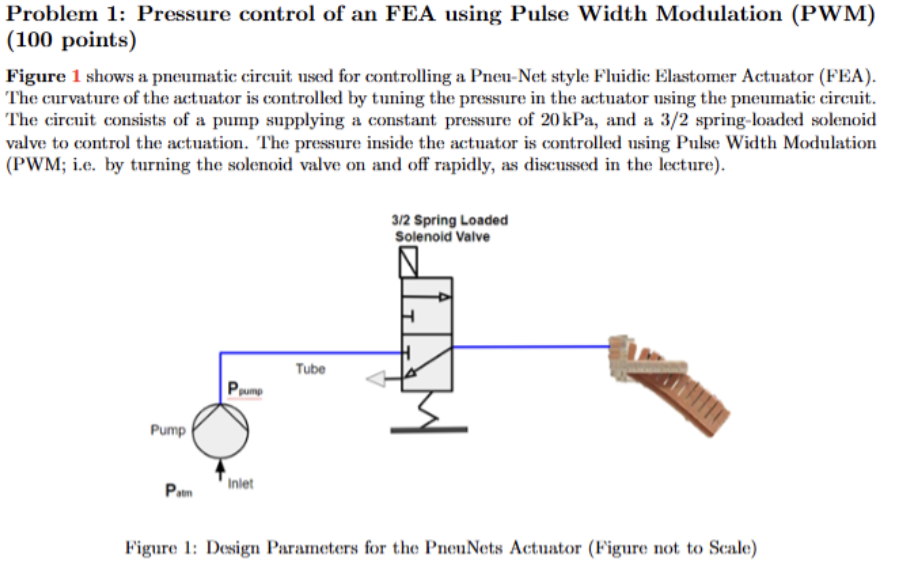


Part B - Actuator Pressure vs Time



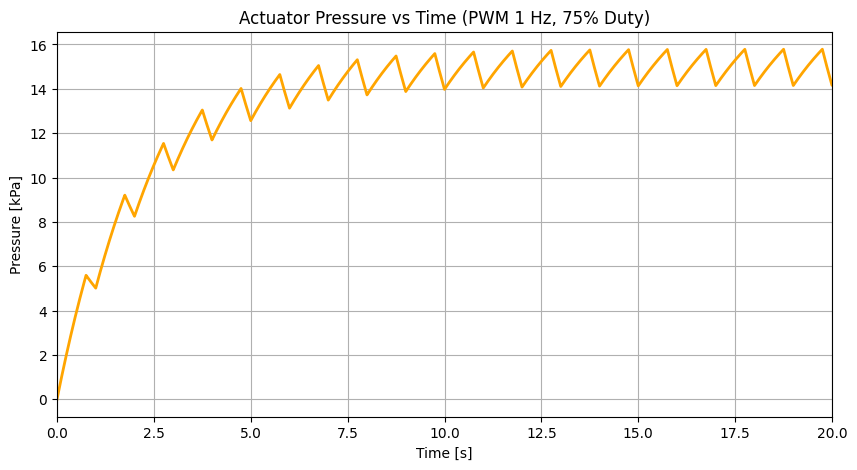

Actuator compliance: 1.633e-06 m³/Pa
Time constant (tau): 2.29 s
Steady-state pressure: 14.16 kPa


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
P_pump = 20_000.0       # Pump pressure (Pa)
R_valve = 1.4e6          # Flow resistance (Pa·s / m³)
dp_per_mass = 1250.0 / 0.0025  # Pa per kg (from 1.25 kPa per 2.5 g)
rho_air = 1.225          # kg/m³, air density
C_act = 1 / (rho_air * dp_per_mass)  # Actuator compliance (m³ / Pa)
tau = R_valve * C_act    # Time constant (s)

# --- PWM Settings ---
freq = 1.0               # Hz (switching frequency)
duty = 0.75              # 75% ON time
T = 1.0 / freq           # Period (s)
t_on = duty * T
t_off = T - t_on

# --- Simulation Parameters ---
t_final = 20.0           # total simulation time (s)
dt = 0.001               # time step (s)
n_steps = int(t_final / dt)
t = np.linspace(0, t_final, n_steps)
p = np.zeros(n_steps)    # pressure array (Pa)

# --- Simulation Loop ---
for i in range(1, n_steps):
    phase = t[i] % T  # where we are in the PWM cycle
    if phase < t_on:  # valve ON (pressurizing)
        dpdt = (P_pump - p[i-1]) / (R_valve * C_act)
    else:             # valve OFF (venting)
        dpdt = -p[i-1] / (R_valve * C_act)
    p[i] = p[i-1] + dpdt * dt

# --- Convert and Plot ---
p_kpa = p / 1000  # convert Pa → kPa

plt.figure(figsize=(10, 5))
plt.plot(t, p_kpa, color='orange', lw=2)
plt.title("Actuator Pressure vs Time (PWM 1 Hz, 75% Duty)")
plt.xlabel("Time [s]")
plt.ylabel("Pressure [kPa]")
plt.grid(True)
plt.xlim(0, t_final)
plt.show()

# --- Optional Output ---
print(f"Actuator compliance: {C_act:.3e} m³/Pa")
print(f"Time constant (tau): {tau:.2f} s")
print(f"Steady-state pressure: {p_kpa[-1]:.2f} kPa")


Part C - Tip Displacement vs Time

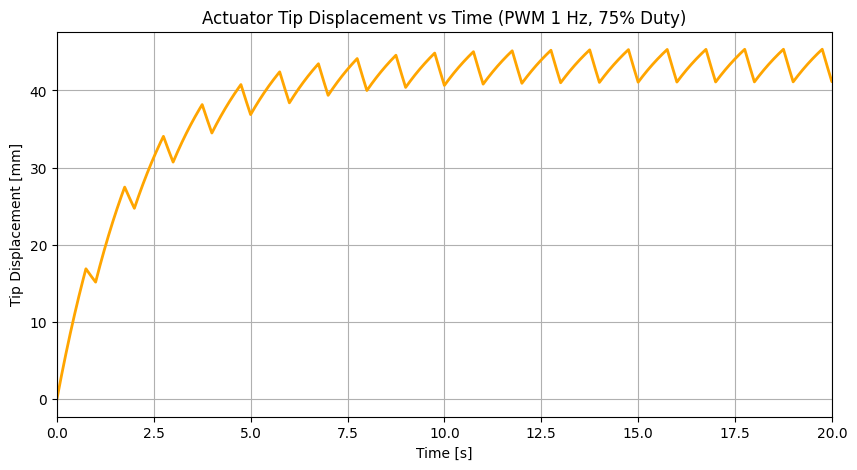

Max tip displacement: 45.33 mm


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
P_pump = 20_000.0       # Pump pressure (Pa)
R_valve = 1.4e6         # Flow resistance (Pa·s / m³)
dp_per_mass = 1250.0 / 0.0025  # Pa per kg (from 1.25 kPa per 2.5 g)
rho_air = 1.225          # kg/m³, air density
C_act = 1 / (rho_air * dp_per_mass)  # Actuator compliance (m³ / Pa)
tau = R_valve * C_act    # Time constant (s)

# --- PWM Settings ---
freq = 1.0               # Hz (switching frequency)
duty = .75               # 75% ON time
T = 1.0 / freq           # Period (s)
t_on = duty * T

# --- Geometric Parameters ---
hc = 0.014                 # Channel height (m)
hb = 0.016                 # Rubber height (m)
Lc = 0.012                 # Channel length (m)
L = 0.116                  # Rubber length (m)
E = 8.0e5                  # Young's Modulus (Pa)
N = 7                      # Number of channels

# --- Simulation Parameters ---
t_final = 20.0           # total simulation time (s)
dt = 0.001               # time step (s)
n_steps = int(t_final / dt)
t = np.linspace(0, t_final, n_steps)
p = np.zeros(n_steps)    # pressure array (Pa)

# --- Simulation Loop ---
for i in range(1, n_steps):
    phase = t[i] % T  # where we are in the PWM cycle
    if phase < t_on:  # valve ON (pressurizing)
        dpdt = (P_pump - p[i-1]) / (R_valve * C_act)
    else:             # valve OFF (venting)
        dpdt = -p[i-1] / (R_valve * C_act)
    p[i] = p[i-1] + dpdt * dt

# --- Compute angle and displacement ---
theta = 2 * N * np.arctan(((Lc * p) / (2 * E)) * (1 / (hb - hc)))

# Avoid divide-by-zero when theta ~ 0 using small-angle approximation Δy ≈ L * θ / 2
delta_y = np.zeros_like(theta)
small = np.abs(theta) < 1e-6
delta_y[small] = L * theta[small] / 2.0
delta_y[~small] = (L / theta[~small]) * (1 - np.cos(theta[~small]))

# --- Plot tip displacement over time ---
plt.figure(figsize=(10, 5))
plt.plot(t, delta_y * 1000, color='orange', lw=2)  # convert m → mm
plt.title("Actuator Tip Displacement vs Time (PWM 1 Hz, 75% Duty)")
plt.xlabel("Time [s]")
plt.ylabel("Tip Displacement [mm]")
plt.grid(True)
plt.xlim(0, t_final)
plt.show()

print(f"Max tip displacement: {np.max(delta_y)*1000:.2f} mm")


Part D - Duty Cycle w/ 1.5cm as max displacement

Approximate duty cycle for Δy_ss = 15.0 mm: 24.79%


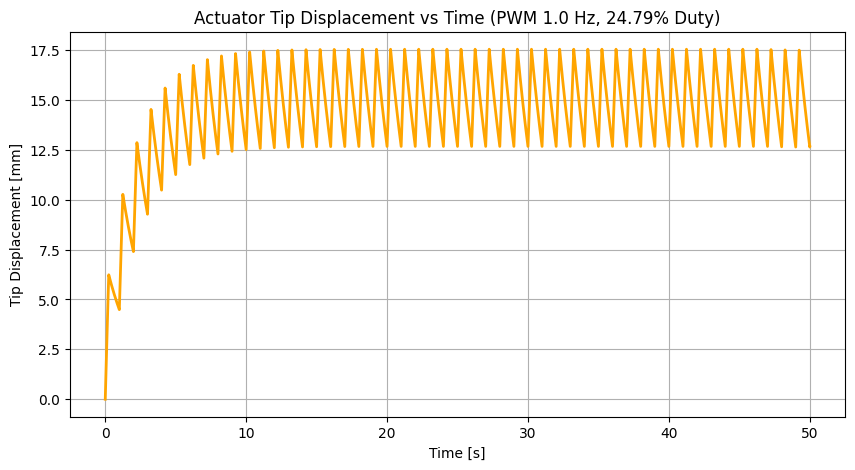

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- System Parameters ---
P_pump = 20_000.0       # Pa
R_valve = 1.4e6         # Pa·s/m³
dp_per_mass = 1250.0 / 0.0025
rho_air = 1.225
C_act = 1 / (rho_air * dp_per_mass)
tau = R_valve * C_act

# --- PWM Settings ---
freq = 1.0               # Hz
T = 1.0 / freq

# --- Geometric Parameters ---
hc = 0.014
hb = 0.016
Lc = 0.012
L = 0.116
E = 8.0e5
N = 7

# --- Simulation Parameters ---
t_final = 50.0           # long enough to reach steady state
dt = 0.001
n_steps = int(t_final / dt)
t = np.linspace(0, t_final, n_steps)

# Target tip displacement
target_dy = 0.015  # m

def simulate_pwm(duty):
    t_on = duty * T
    p = np.zeros(n_steps)

    for i in range(1, n_steps):
        phase = t[i] % T
        if phase < t_on:
            dpdt = (P_pump - p[i-1]) / (R_valve * C_act)
        else:
            dpdt = -p[i-1] / (R_valve * C_act)
        p[i] = p[i-1] + dpdt * dt

    theta = 2 * N * np.arctan((Lc * p) / (2 * E * (hb - hc)))
    delta_y = np.zeros_like(theta)
    small = np.abs(theta) < 1e-6
    delta_y[small] = L * theta[small] / 2.0
    delta_y[~small] = (L / theta[~small]) * (1 - np.cos(theta[~small]))

    # Return steady-state displacement (average over last 5 seconds)
    return np.mean(delta_y[-int(5/dt):])

# --- Define function to find root ---
def duty_to_target(duty):
    return simulate_pwm(duty) - target_dy

# --- Find duty cycle using brentq ---
duty_target = brentq(duty_to_target, 0.1, 0.9)  # search between 10% and 90%
print(f"Approximate duty cycle for Δy_ss = {target_dy*1000:.1f} mm: {duty_target*100:.2f}%")

# --- Plot the time response ---
delta_y = simulate_pwm(duty_target)

# For full time response
t_on = duty_target * T
p = np.zeros(n_steps)
for i in range(1, n_steps):
    phase = t[i] % T
    if phase < t_on:
        dpdt = (P_pump - p[i-1]) / (R_valve * C_act)
    else:
        dpdt = -p[i-1] / (R_valve * C_act)
    p[i] = p[i-1] + dpdt * dt

theta = 2 * N * np.arctan((Lc * p) / (2 * E * (hb - hc)))
delta_y = np.zeros_like(theta)
small = np.abs(theta) < 1e-6
delta_y[small] = L * theta[small] / 2.0
delta_y[~small] = (L / theta[~small]) * (1 - np.cos(theta[~small]))

plt.figure(figsize=(10,5))
plt.plot(t, delta_y*1000, color='orange', lw=2)
plt.title(f"Actuator Tip Displacement vs Time (PWM {freq} Hz, {duty_target*100:.2f}% Duty)")
plt.xlabel("Time [s]")
plt.ylabel("Tip Displacement [mm]")
plt.grid(True)
plt.show()


Part E - Reduce Oscillations

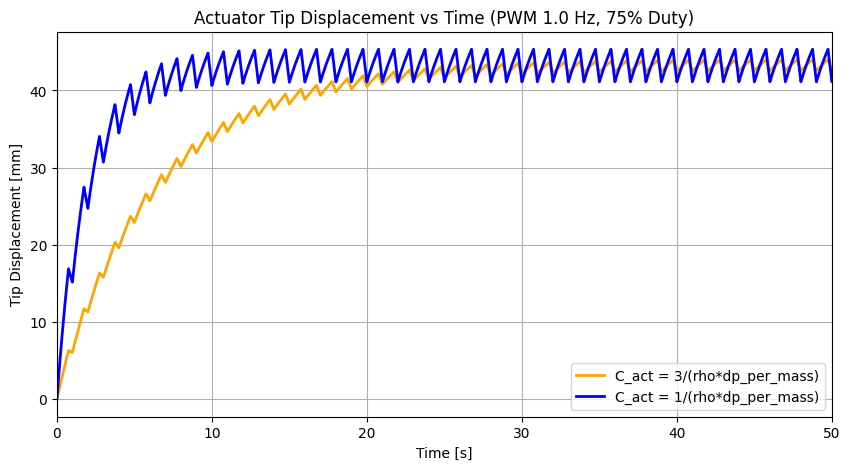

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
P_pump = 20_000.0       # Pa
R_valve = 1.4e6         # Pa·s/m³
dp_per_mass = 1250.0 / 0.0025
rho_air = 1.225

# --- PWM Settings ---
freq = 1.0               # Hz
T = 1.0 / freq
duty = 0.75              # can use previous duty or find new for each if needed

# --- Geometric Parameters ---
hc = 0.014
hb = 0.016
Lc = 0.012
L = 0.116
E = 8.0e5
N = 7

# --- Simulation Parameters ---
t_final = 50.0
dt = 0.001
n_steps = int(t_final / dt)
t = np.linspace(0, t_final, n_steps)

# --- Different Actuator Compliances ---
C_list = [3 / (rho_air * dp_per_mass), 1 / (rho_air * dp_per_mass)]
labels = ['C_act = 3/(rho*dp_per_mass)', 'C_act = 1/(rho*dp_per_mass)']
colors = ['orange', 'blue']

plt.figure(figsize=(10,5))

for C_act, label, color in zip(C_list, labels, colors):
    p = np.zeros(n_steps)
    t_on = duty * T

    for i in range(1, n_steps):
        phase = t[i] % T
        if phase < t_on:
            dpdt = (P_pump - p[i-1]) / (R_valve * C_act)
        else:
            dpdt = -p[i-1] / (R_valve * C_act)
        p[i] = p[i-1] + dpdt * dt

    # --- Convert pressure to tip displacement ---
    theta = 2 * N * np.arctan((Lc * p) / (2 * E * (hb - hc)))
    delta_y = np.zeros_like(theta)
    small = np.abs(theta) < 1e-6
    delta_y[small] = L * theta[small] / 2.0
    delta_y[~small] = (L / theta[~small]) * (1 - np.cos(theta[~small]))

    plt.plot(t, delta_y*1000, color=color, lw=2, label=label)

plt.title(f"Actuator Tip Displacement vs Time (PWM {freq} Hz, {duty*100:.0f}% Duty)")
plt.xlabel("Time [s]")
plt.ylabel("Tip Displacement [mm]")
plt.grid(True)
plt.legend()
plt.xlim(0, t_final)
plt.show()
